# **Modelo Phi-four**

> Autor: Camila Borges Sena

> E-mail: camila19sena@gmail.com

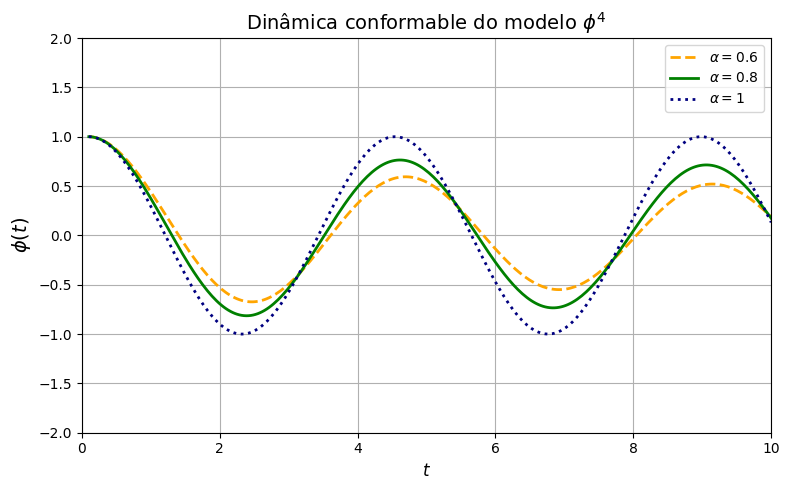

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# Parâmetros do modelo phi^4
# -----------------------------
m2 = -1.0
lam = 1.0

# mínimo clássico
phi0 = np.sqrt(-6 * m2 / lam)

# massa efetiva
m_eff2 = m2 + (lam / 2.0) * phi0**2

# Tempo
t_span = (0.1, 10)
t_vals = np.linspace(*t_span, 300)

# Valores de alpha
alphas = [0.6, 0.8, 1.0]
colors = ['orange', 'green', 'navy']
styles = ['--', '-', ':']
labels = [r'$\alpha = 0.6$', r'$\alpha = 0.8$', r'$\alpha = 1$']

# -----------------------------
# Equação conformable
# -----------------------------
def conformable_phi4(t, y, alpha):
    phi, dphi = y
    ddphi = -(1 - alpha)/t * dphi - m_eff2 * phi
    return [dphi, ddphi]

# -----------------------------
# Gráfico
# -----------------------------
plt.figure(figsize=(8, 5))

for alpha, color, style, label in zip(alphas, colors, styles, labels):

    sol = solve_ivp(
        conformable_phi4,
        t_span,
        y0=[1.0, 0.0],  # condição inicial
        t_eval=t_vals,
        args=(alpha,)
    )

    plt.plot(sol.t, sol.y[0], style,
             color=color, linewidth=2, label=label)

plt.xlabel(r'$t$', fontsize=12)
plt.ylabel(r'$\phi(t)$', fontsize=14)
plt.xlim(0, 10)
plt.ylim(-2, 2)
plt.title(r'Dinâmica conformable do modelo $\phi^4$', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

